## Task 2

## Part 1

### Install dependencies
We first install the libraries needed for Persian NLP: hazm, parsivar, regex for cleaning, and bidi/arabic_reshaper for proper display.

In [181]:
!pip install hazm parsivar regex arabic-reshaper python-bidi nltk wordcloud matplotlib pandas transformers torch lancedb sentence-transformers


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Imports
Now we import the necessary libraries for preprocessing.


In [182]:
import re
import unicodedata
from hazm import Normalizer, WordTokenizer, SentenceTokenizer, Lemmatizer, stopwords_list
import arabic_reshaper
from bidi.algorithm import get_display


### Configurations
Here we define mappings (Arabic → Persian letters), slang dictionary, and regex patterns for cleaning.

In [183]:
ARABIC_TO_PERSIAN_MAP = {
    'ي': 'ی',
    'ك': 'ک',
    'ى': 'ی',
    'ۀ': 'ه',
    'ؤ': 'و',
    'إ': 'ا',
    'أ': 'ا',
    'ٱ': 'ا',
    'ﻻ': 'لا'
}

SLANG_MAP = {
    'خخ': 'خنده',
    'یه': 'یک',
    'ههه': 'خنده',
    'مرسي': 'متشکرم',
    'مرسی': 'متشکرم',
    'کلي': 'خیلی',
    'کلی': 'خیلی'
}


DIACRITICS_REGEX = re.compile(r'[\u064B-\u065F\u0610-\u061A\u06D6-\u06DC\u06DF-\u06E8\u06EA-\u06ED]')
UNWANTED_CHARS_RE = re.compile(r'[\u200c\u200b\u200e\u200f\u202a-\u202e]')
PUNCT_RE = re.compile(r'([!?،؛\.\-—ـ])\1+')
REPEAT_LETTER_RE = re.compile(r'(.)(\1){2,}', flags=re.UNICODE)

normalizer = Normalizer()
word_tokenizer = WordTokenizer()
sent_tokenizer = SentenceTokenizer()
stemmer = Stemmer()
lemmatizer = Lemmatizer()
STOPWORDS = set(stopwords_list())


### Cleaning functions
We now create functions for: replacing Arabic chars, removing diacritics, removing unwanted characters, normalizing punctuation, reducing repeated letters, and replacing slang.


In [184]:
def replace_arabic_letters(text: str) -> str:
    for a, p in ARABIC_TO_PERSIAN_MAP.items():
        text = text.replace(a, p)
    return text

def remove_diacritics(text: str) -> str:
    text = DIACRITICS_REGEX.sub('', text)
    text = ''.join(ch for ch in text if unicodedata.category(ch) != 'Mn')
    return text

def remove_unwanted_chars(text: str) -> str:
    text = UNWANTED_CHARS_RE.sub('', text)
    return re.sub(r'\s+', ' ', text).strip()

def normalize_punctuation(text: str) -> str:
    text = PUNCT_RE.sub(r'\1', text)
    text = text.replace(',', '،')
    return text

def normalize_repeated_letters(text: str, keep=1) -> str:
    def repl(m):
        return m.group(1) * keep
    return REPEAT_LETTER_RE.sub(repl, text)

def replace_slangs(text: str, slang_map=SLANG_MAP) -> str:
    for slang, std in slang_map.items():
        text = re.sub(r'\b' + re.escape(slang) + r'\b', std, text)
    return text

def replace_laughter_text(text):
    text = re.sub(r'خ{2,}', ' خنده ', text)
    text = re.sub(r'ه{2,}', ' خنده ', text)
    return text

def replace_laughter_tokens(tokens):
    return ['خنده' if re.fullmatch(r'(خ|ه){2,}', t) else t for t in tokens]


### Tokenization and linguistic processing
Next, we tokenize the text, remove stopwords, and optionally apply stemming or lemmatization.


In [185]:
def tokenize(text: str):
    return word_tokenizer.tokenize(text)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in STOPWORDS and t.strip() != '']

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]


### Full preprocessing pipeline
This function chains all the previous steps together into one pipeline.


In [186]:
def preprocess_text(text: str,
                    do_replace_arabic=True,
                    do_diacritics=True,
                    do_normalize_hazm=True,
                    do_remove_unwanted=True,
                    do_punct_norm=True,
                    do_repeat_norm=True,
                    do_slang_replace=False,
                    do_lemmatize=False,
                    do_stem=False,
                    return_tokens=True):
    if text is None:
        return []
    text = text.strip()
    if do_replace_arabic:
        text = replace_arabic_letters(text)
    if do_normalize_hazm:
        text = normalizer.normalize(text)
    if do_diacritics:
        text = remove_diacritics(text)
    if do_remove_unwanted:
        text = remove_unwanted_chars(text)
    if do_punct_norm:
        text = normalize_punctuation(text)
    if do_repeat_norm:
        text = normalize_repeated_letters(text, keep=1)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    if do_slang_replace:
        tokens = [SLANG_MAP.get(tok, tok) for tok in tokens]
    tokens = replace_laughter_tokens(tokens)
    if do_lemmatize:
        tokens = lemmatize_tokens(tokens)
    elif do_stem:
        tokens = stem_tokens(tokens)
    return tokens if return_tokens else ' '.join(tokens)


### Testing the pipeline
Let’s try the preprocessing pipeline on a few sample sentences.


In [187]:
from IPython.display import display, HTML
import arabic_reshaper
from bidi.algorithm import get_display

def display_rtl(text):
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)
    html = f'<div style="direction: rtl; text-align: right; font-family: Tahoma, sans-serif;">{bidi_text}</div>'
    display(HTML(html))


samples = [
    "سلاممممممممم!!!!! حالتون چطوره؟؟؟؟    من خيلى خستم",
    "مرسيییییی داداش! خخخخخخخخخ",
    "این یک متن با ي و ك و diacritics: مَرْحَبًا"
]

for s in samples:
    proc = preprocess_text(s)
    print("ORIG:", s)
    print("PROC:", proc)
    print("RTL:", rtl_display(" ".join(proc)))
    print("---")

ORIG: سلاممممممممم!!!!! حالتون چطوره؟؟؟؟    من خيلى خستم
PROC: ['سلام', '!', 'حالتون', 'چطوره', '؟', 'خستم']
RTL: ﻢﺘﺴﺧ ؟ ﻩﺭﻮﻄﭼ ﻥﻮﺘﻟﺎﺣ ! ﻡﻼﺳ
---
ORIG: مرسيییییی داداش! خخخخخخخخخ
PROC: ['مرسیی', 'داداش', '!', 'خنده']
RTL: ﻩﺪﻨﺧ ! ﺵﺍﺩﺍﺩ ﯽﯿﺳﺮﻣ
---
ORIG: این یک متن با ي و ك و diacritics: مَرْحَبًا
PROC: ['متن', 'بای', 'ک', 'diacritics', ':', 'مرحبا']
RTL: ﺎﺒﺣﺮﻣ : diacritics ﮎ ﯼﺎﺑ ﻦﺘﻣ
---


## Part 2

### Display 2 Sample Questions with Corresponding Answers
We first take a look at 2 random questions and their answers to understand the data structure.


In [188]:
import json
import pandas as pd

with open('./PerCQA_JSON_Format.json', 'r', encoding='utf-8-sig') as f:
    data = json.load(f)
    
df = pd.json_normalize(
    data,
    record_path=['Comments'],  
    meta=['QID', 'QBody', 'QSubject', 'QUsername', 'QDATE', 'QTYPE'],  # top-level question fields
    errors='ignore'
)

df = df.rename(columns={
    'CBodyClean': 'Answer',
    'CUsername': 'AnswerUser',
    'LabelDate': 'AnswerDate'
})

df['QDATE'] = pd.to_datetime(df['QDATE'], errors='coerce')
df['AnswerDate'] = pd.to_datetime(df['AnswerDate'], errors='coerce')

df.head()

sample_qids = df['QID'].drop_duplicates().sample(2, random_state=42).values

for qid in sample_qids:
    question = df[df['QID'] == qid]['QBody'].iloc[0]  
    answers = df[df['QID'] == qid]['Answer'].tolist()
    
    print("QID:", qid)
    print("Question:", question)
    print("Answers:")
    for i, ans in enumerate(answers, 1):
        print(f"{i}. {ans}")
    print("\n" + "-"*50 + "\n")


QID: 4153534
Question: بچم یک سال و یک ماهشه اما خوابش کم هست در شب هشت یا نه ساعت اما با داد و گریه هی بیدار میشه. در روزم دو تا یک ساعت میخوابه.
Answers:
1. دندون در میاره شاید دختر من تا ساعت 12 میخوابه البته شب ساعت 2 میخوابه بعدظهرم 5 تا 9
2. 12 بیدار میشه 6 میخوابه دوباره 12 شب میخوابه
3. خواب بچه به زمان خواب خودتون بستگی داره. باید اول خودتون به موقع بخوابین و بعد اون هم عادت میکنه. درباره الان حداقل 9 شب باید خواب باشن تا 9 صبح. وسطاش بیدار شه برای شیر مشکلی نداره. ولی این 12 ساعت باید در آرامش باشه

--------------------------------------------------

QID: 3187059
Question: پدیا شور خیلی وقته گیر نمیارم شیراز. کسی اطلاع داره؟ . بقیه شهرها چی؟
Answers:
1. برو از دیجیکالا جستجو کن. 
2. چی هس؟
3. عه آسناتا چ باهم چ مثل هم😂
4. گرون شده دیگه همه جا نمیارن. جایگزینش اومده به نظرم
5. مکمل غذایی کودک هست ، مثل شیر خشک غنی شده. اما نمیشه پیدا کرد. 
6. یک پیج مکمل غذایی تو اینستا هست که همه نوع مکمل غذایی کودکان را دارد . 
7. بهم بگو کدوم پیج هست
8. تازگی دنبالش نبودم ، چندسال پیش هم که

### Average and Median Lengths
We compute word count and character count for both questions and answers across the dataset.


In [189]:
df['Q_word_count'] = df['QBody'].apply(lambda x: len(str(x).split()))
df['Q_char_count'] = df['QBody'].apply(lambda x: len(str(x)))
df['A_word_count'] = df['Answer'].apply(lambda x: len(str(x).split()))
df['A_char_count'] = df['Answer'].apply(lambda x: len(str(x)))

print("Questions - Avg words:", df['Q_word_count'].mean(), "Median words:", df['Q_word_count'].median())
print("Questions - Avg chars:", df['Q_char_count'].mean(), "Median chars:", df['Q_char_count'].median())
print("Answers - Avg words:", df['A_word_count'].mean(), "Median words:", df['A_word_count'].median())
print("Answers - Avg chars:", df['A_char_count'].mean(), "Median chars:", df['A_char_count'].median())



Questions - Avg words: 43.989083962521605 Median words: 31.0
Questions - Avg chars: 217.28859274083507 Median chars: 156.0
Answers - Avg words: 18.44041662876376 Median words: 13.0
Answers - Avg chars: 89.768761939416 Median chars: 62.0


### Distribution of Question and Answer Lengths
We visualize word count and character count distributions using histograms and boxplots.


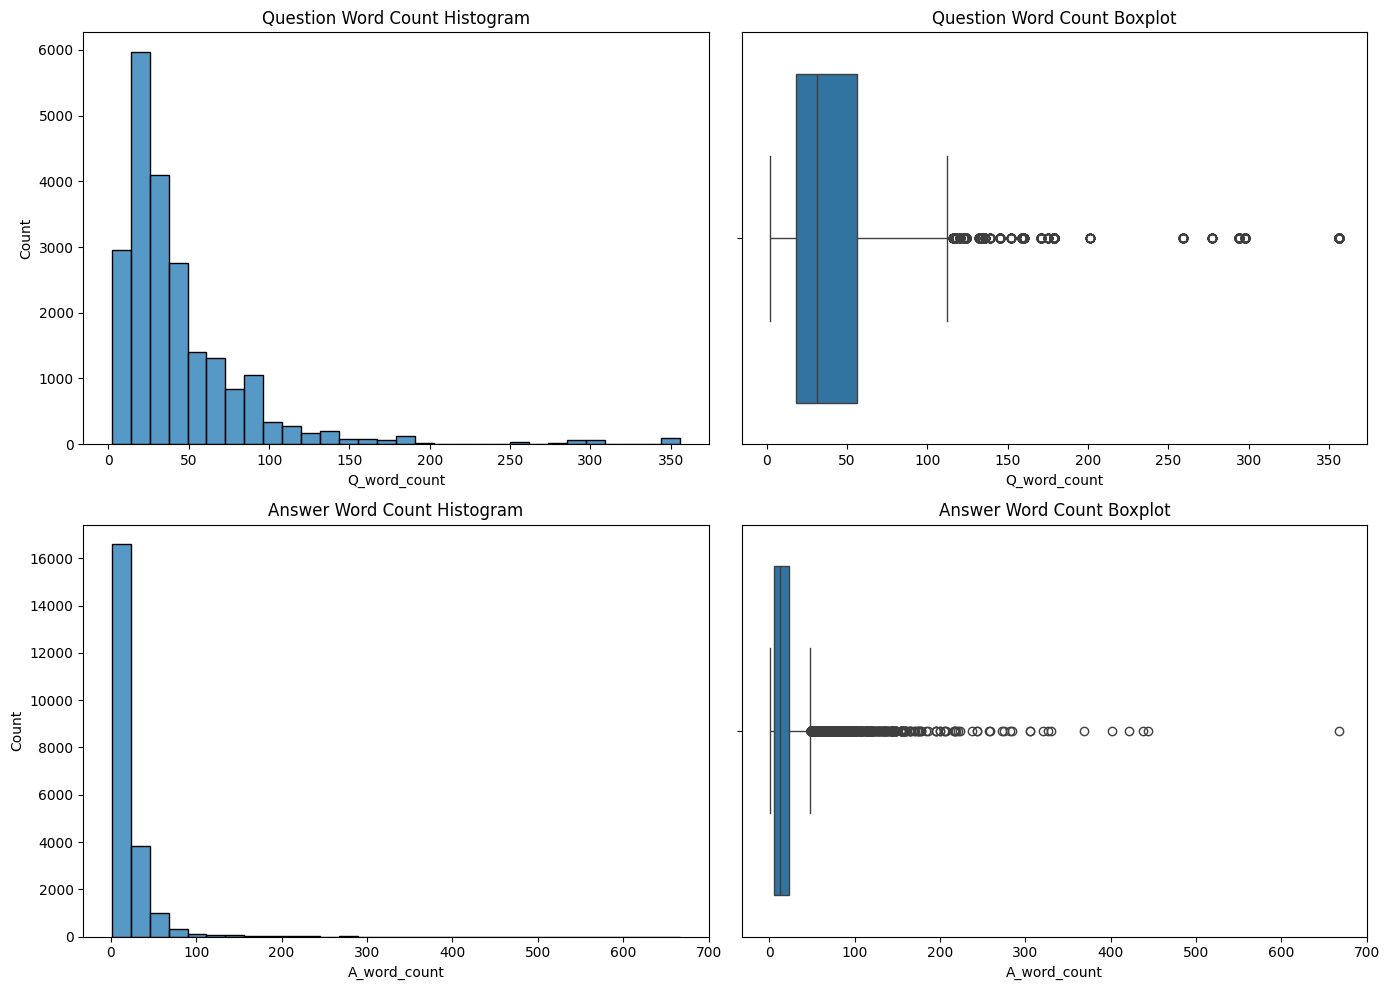

In [190]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.histplot(df['Q_word_count'], bins=30, ax=axes[0,0])
axes[0,0].set_title("Question Word Count Histogram")
sns.boxplot(x=df['Q_word_count'], ax=axes[0,1])
axes[0,1].set_title("Question Word Count Boxplot")

sns.histplot(df['A_word_count'], bins=30, ax=axes[1,0])
axes[1,0].set_title("Answer Word Count Histogram")
sns.boxplot(x=df['A_word_count'], ax=axes[1,1])
axes[1,1].set_title("Answer Word Count Boxplot")

plt.tight_layout()
plt.show()


### Questions with Highest Number of Answers
We group by QID to find which questions get the most responses.


In [191]:
answer_counts = df.groupby('QID').size().sort_values(ascending=False)
top_questions = answer_counts.head(5)
top_questions


QID
1556257    315
1577970    313
1559359    215
1555428    215
1578477    166
dtype: int64

### User Activity Patterns by Hour and Day
Using CDate, we extract hour and day information to visualize activity.


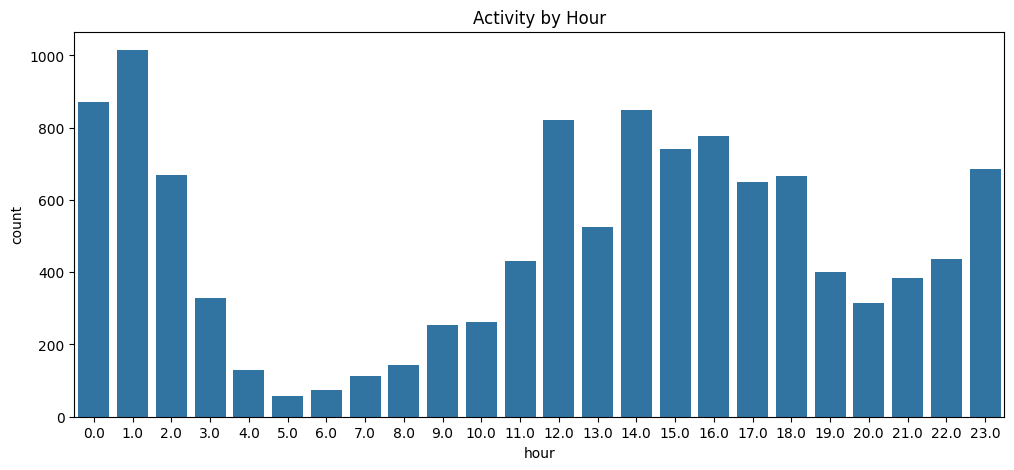

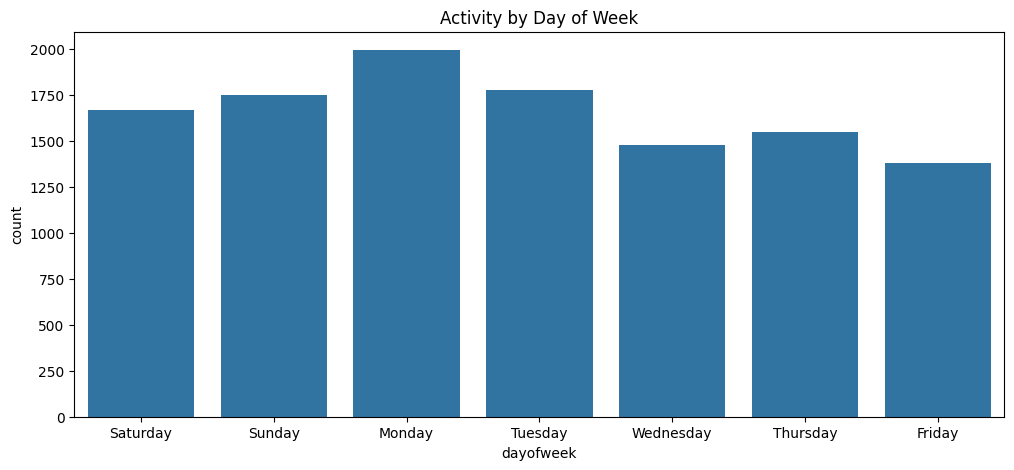

In [192]:
df['CDate'] = pd.to_datetime(df['CDate'])
df['hour'] = df['CDate'].dt.hour
df['dayofweek'] = df['CDate'].dt.day_name()

plt.figure(figsize=(12,5))
sns.countplot(x='hour', data=df)
plt.title("Activity by Hour")
plt.show()

plt.figure(figsize=(12,5))
sns.countplot(x='dayofweek', data=df, order=['Saturday','Sunday','Monday','Tuesday','Wednesday','Thursday','Friday'])
plt.title("Activity by Day of Week")
plt.show()


### Heatmap: Activity Intensity Across Hour and Day
We visualize activity intensity using a pivot table.


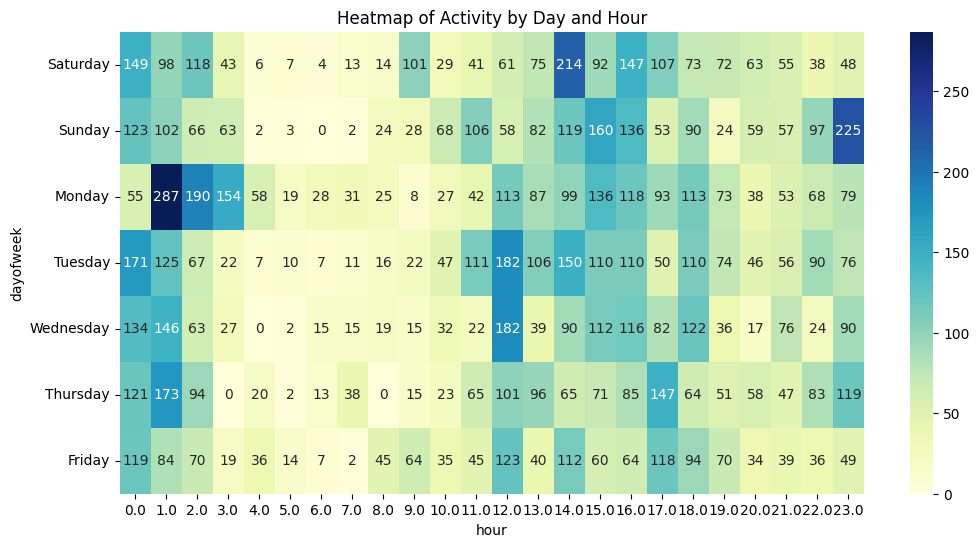

In [193]:
activity_pivot = df.pivot_table(index='dayofweek', columns='hour', values='QID', aggfunc='count').fillna(0)
activity_pivot = activity_pivot.reindex(['Saturday','Sunday','Monday','Tuesday','Wednesday','Thursday','Friday'])

plt.figure(figsize=(12,6))
sns.heatmap(activity_pivot, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Heatmap of Activity by Day and Hour")
plt.show()


### Top Answer Contributors
Count number of answers per user and visualize top 10 contributors.


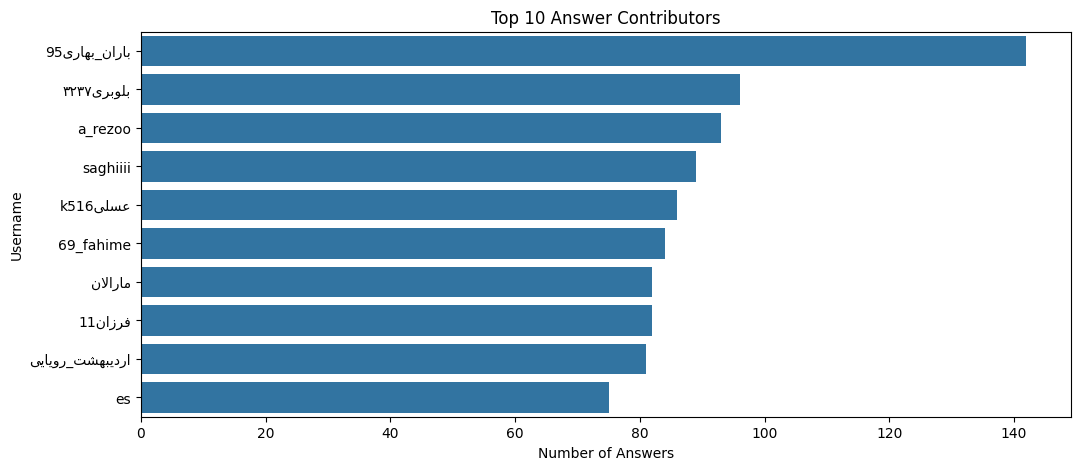

In [194]:
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display

top_users = df.groupby('AnswerUser').size().sort_values(ascending=False).head(10)

y_labels_rtl = [get_display(arabic_reshaper.reshape(str(u))) for u in top_users.index]

plt.figure(figsize=(12,5))
sns.barplot(x=top_users.values, y=y_labels_rtl)
plt.title("Top 10 Answer Contributors")
plt.xlabel("Number of Answers")
plt.ylabel("Username")
plt.show()


### Most Frequent Words and Word Clouds
We extract the most frequent words in questions and answers (after preprocessing/stopword removal).


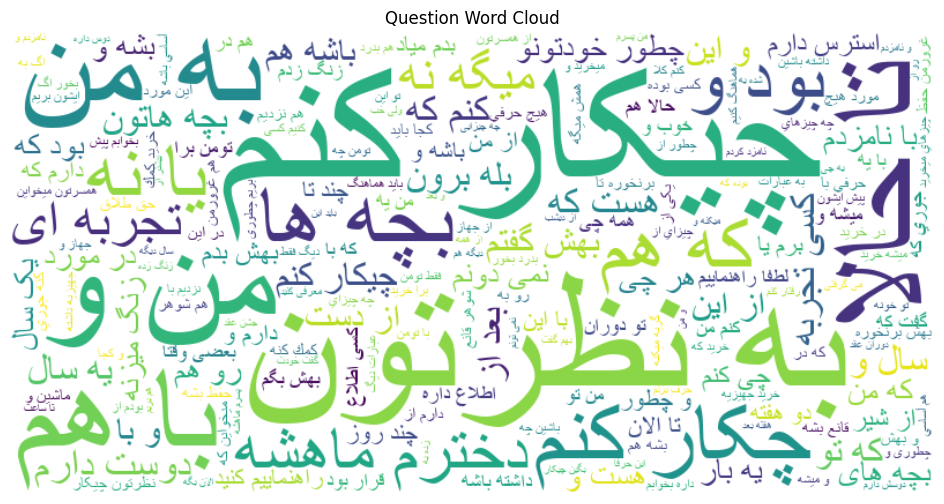

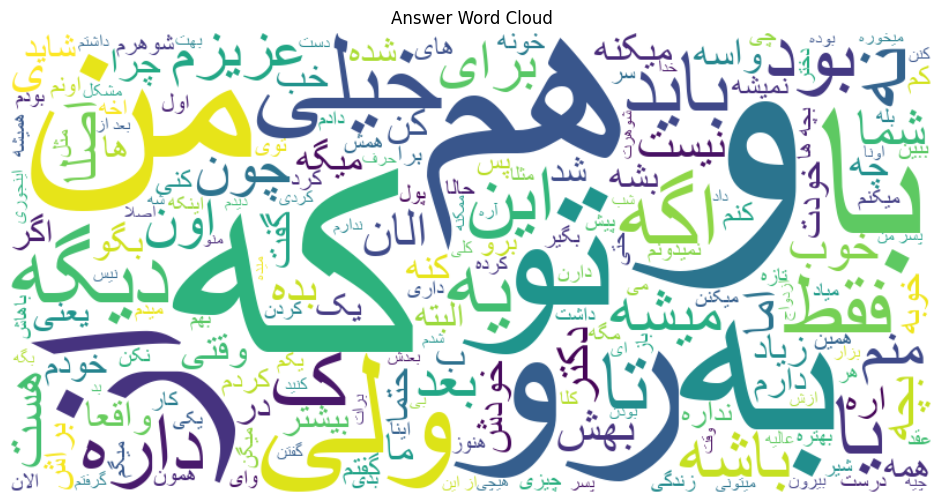

In [195]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display
import re

def clean_text(text):
    return re.sub(r'[\u2066\u2067\u2068\u2069]', '', text)

all_questions = " ".join(df['QBody'].astype(str).tolist())
all_answers = " ".join(df['Answer'].astype(str).tolist())

all_questions_clean = get_display(arabic_reshaper.reshape(clean_text(all_questions)))
all_answers_clean = get_display(arabic_reshaper.reshape(clean_text(all_answers)))

q_wordcloud = WordCloud(width=800, height=400, background_color='white', font_path='arial.ttf').generate(all_questions_clean)
a_wordcloud = WordCloud(width=800, height=400, background_color='white', font_path='arial.ttf').generate(all_answers_clean)

plt.figure(figsize=(14,6))
plt.imshow(q_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Question Word Cloud")
plt.show()

plt.figure(figsize=(14,6))
plt.imshow(a_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Answer Word Cloud")
plt.show()


### N-gram Analysis (unigram, bigram, trigram)
We compute frequencies of unigrams, bigrams, and trigrams, both before and after stopword removal.


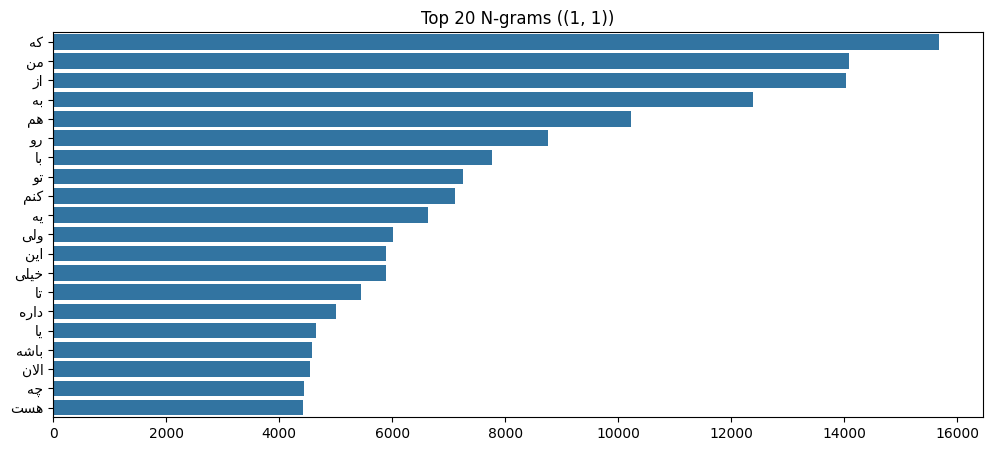

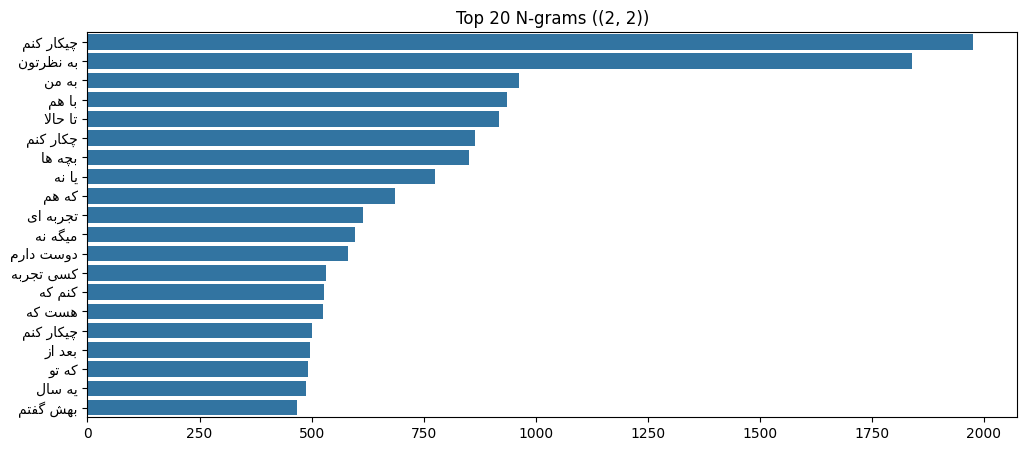

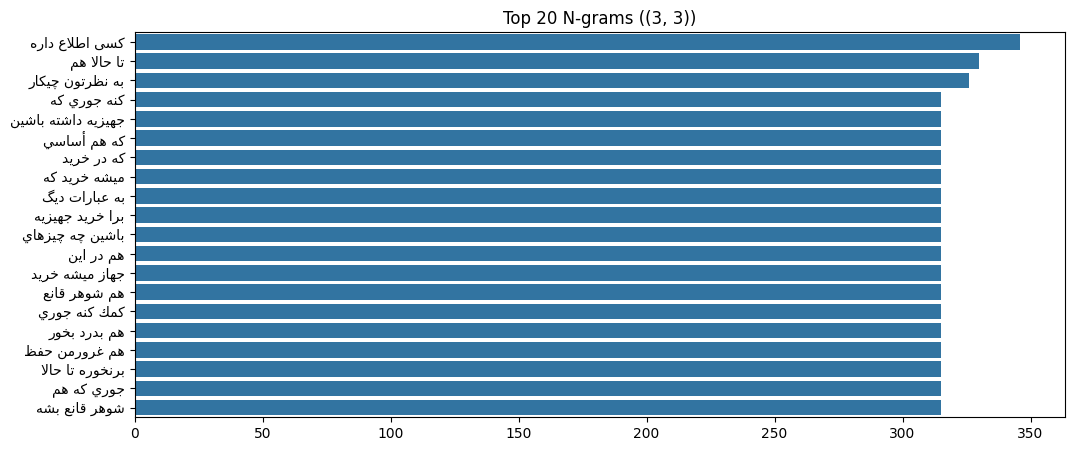

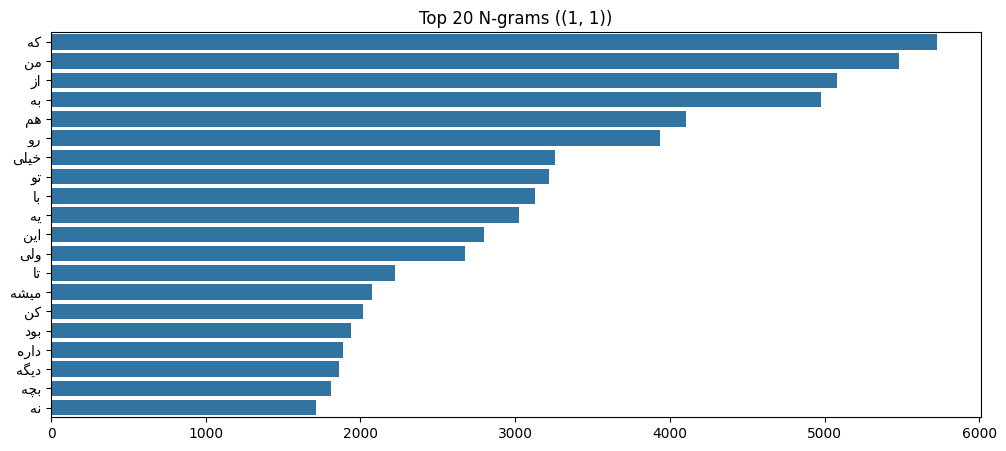

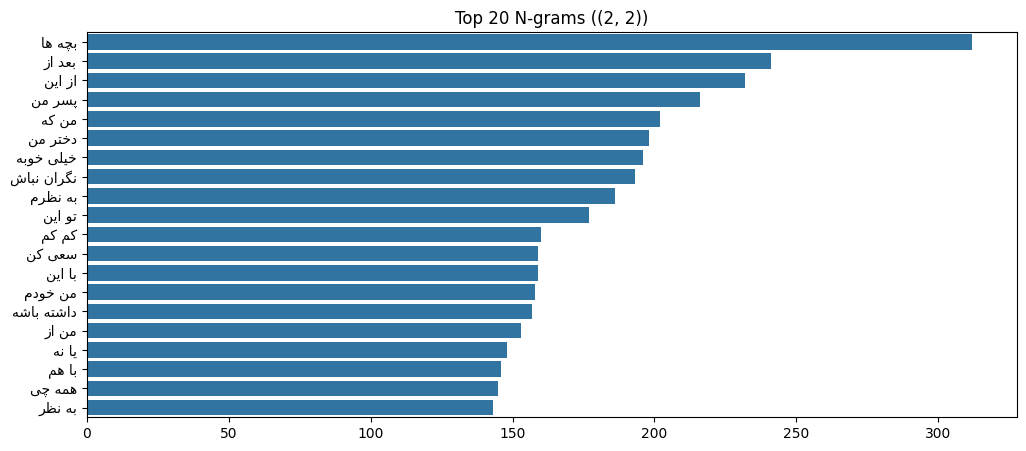

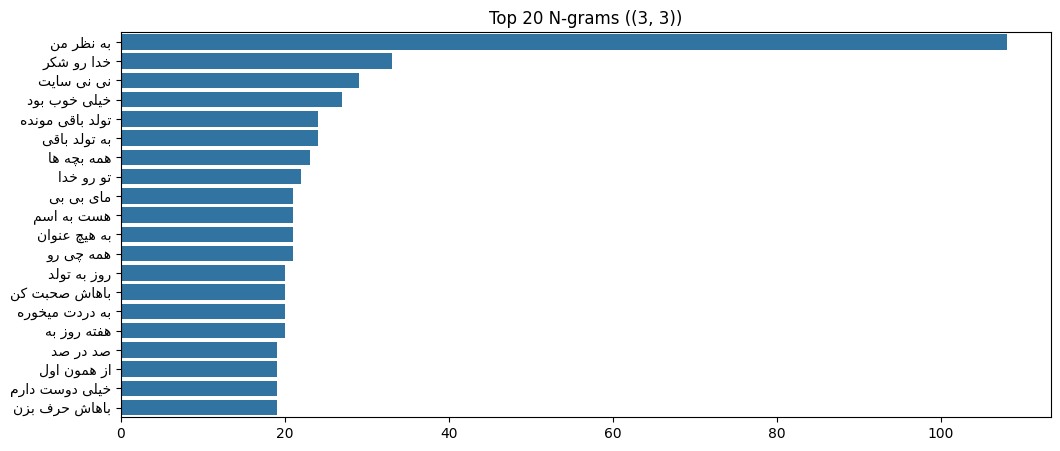

In [196]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display
import numpy as np

def plot_ngrams(texts, ngram_range=(1,1), top_k=20):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words=None)
    X = vectorizer.fit_transform(texts)
    
    freqs = np.array(X.sum(axis=0)).flatten()  
    ngrams = vectorizer.get_feature_names_out()
    
    top_idx = np.argsort(freqs)[::-1][:top_k]
    top_ngrams = [ngrams[i] for i in top_idx]
    top_counts = [freqs[i] for i in top_idx]
    
    top_ngrams_rtl = [get_display(arabic_reshaper.reshape(t)) for t in top_ngrams]
    
    plt.figure(figsize=(12,5))
    sns.barplot(x=top_counts, y=top_ngrams_rtl)
    plt.title(f"Top {top_k} N-grams ({ngram_range})")
    plt.show()
    
plot_ngrams(df['QBody'].astype(str), ngram_range=(1,1))
plot_ngrams(df['QBody'].astype(str), ngram_range=(2,2))
plot_ngrams(df['QBody'].astype(str), ngram_range=(3,3))

plot_ngrams(df['Answer'].astype(str), ngram_range=(1,1))
plot_ngrams(df['Answer'].astype(str), ngram_range=(2,2))
plot_ngrams(df['Answer'].astype(str), ngram_range=(3,3))


## Part 3

### Load PerCQA Dataset
Load the JSON dataset and keep only question-level information (QID and QBody) 
for semantic search analysis.


In [197]:
import pandas as pd
import json

with open('./PerCQA_JSON_Format.json', 'r', encoding='utf-8-sig') as f:
    data = json.load(f)

questions = pd.DataFrame(data)[['QID', 'QBody']]
questions.head()


,QID,QBody
0,1550088,دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چ...
1,1558609,من خودم حس میکنم اشتباهم گیر دادن بیخودی و غر ...
2,1587820,سالگرد ازدواجم نزدیکه چی بخرم. سالگرد دوممونه....
3,4414921,دختر من چهارده ماهه است. آیا برای تشخیص پرانتز...
4,3109668,چه پمادی بزنم و از چیه اینجور شده . واضح نیس...


### Generate Sample Embedding
Use the bge-m3 embedding model to encode a sample question.
The output is a high-dimensional vector capturing semantic meaning.
Each component corresponds to a feature in embedding space.


In [198]:
from transformers import AutoModel, AutoTokenizer
import torch

tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")
model = AutoModel.from_pretrained("BAAI/bge-m3")

text = "سلام"
inputs = tokenizer(text, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
    
embedding = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()



### Connect to LanceDB
Create a connection to a local LanceDB instance and define a custom embedding function 
using bge-m3 in dense mode. Embeddings will be automatically generated during insertion.
    

In [199]:
from lancedb import connect
from lancedb.embeddings import TextEmbeddingFunction
from transformers import AutoModel, AutoTokenizer
import torch
import numpy as np

tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")
model = AutoModel.from_pretrained("BAAI/bge-m3")

class BGEEmbedding(TextEmbeddingFunction):
    def __init__(self):
        super().__init__()

    def generate_embeddings(self, texts):
        if isinstance(texts, str):
            texts = [texts]
        inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)
        with torch.no_grad():
            outputs = model(**inputs)
        vectors = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        return [v.astype(np.float32) for v in vectors]

    @property
    def ndims(self):
        return 1024  

embedding_fn = BGEEmbedding()

db = connect("./lancedb_percqa")



### Create LanceDB Table
Define the table schema with:
- `qid`: unique question ID
- `qbody`: raw question text
- `embedding`: vector representation automatically generated


In [201]:
from lancedb import connect
import pyarrow as pa

schema = pa.schema([
    pa.field("qid", pa.string()),  # since you cast qid to str
    pa.field("qbody", pa.string()),
    pa.field("embedding", pa.list_(pa.float32(), 1024)),  # vector column
])


records = []
for _, row in questions.iterrows():
    records.append({
        "qid": str(row["QID"]),
        "qbody": row["QBody"],
        "embedding": bge_m3_embedding(row["QBody"])
    })


table = db.create_table(
    name="questions",
    schema=schema,
    data=records,
    mode="overwrite" 
)




### Perform Semantic Search
Retrieve the top 5 semantically similar questions for multiple user queries.
This demonstrates the advantage of embedding-based search.


In [202]:
queries = [
    "چطور مشکل رابطه با همسرم را حل کنم؟",
    "بهترین روش برای کاهش استرس چیست؟",
    "تجربه بچه‌دار شدن چگونه است؟",
    "چطور خستگی مداوم را درمان کنم؟",
    "چطور اعتماد به نفس خود را بالا ببرم؟"
]
print("===== Semantic Search Results =====")
for q in queries:
    q_vector = bge_m3_embedding(q)
    results = (
        table.search(q_vector, vector_column_name="embedding")
        .limit(5)
        .to_list()
    )
    print("Query:", q)
    for r in results:
        print("-", r["qbody"])
    print("---")


===== Semantic Search Results =====
Query: چطور مشکل رابطه با همسرم را حل کنم؟
- من تازه متاهل شدم یعنی تو دوران عقد هستم خیلی دوست دارم از تجربیات موفق دیگر خانومها استفاده کنم که چجور با همسرم از همین الان رفتار کنم که ازم فراری نباشه با من بودن و به هرچیزی ترجیح بده به قول خودتون تو مشتم باشه
- دوستان همونطور که دیشب گفتم شوهرم مثل قبل نیست و گفته از رابطمون زده شده . منم دارم سعی میکنم درستش کنم و باهاش راه بیام و مهربون باشم تا خوب باشه اما هی استرس دارم و بی قرار و همش دنبال یک راهی ام که بفهمم دیگه زده نیست و خیالم راحت شه. با راهنمایی دوستان متوجه شدم و فکر میکنم ک من ناراحتم ک چرا بحث نمیکنیم ک اون بیاد نازمو بکشه تا من ازاین طریق مطمئن بشم که همه چی خوبه و دیگه زده نیست ازم!!!ولی خب تقصیر خودشه حرف نمیزنه ک من بفهمم. به نظرتون چیکار کنم که این حس ها ازم دور شه و بجای اینکه بخوام مطمئن شم خوبه کاری کنم که حس ارامش و خوب بودن بهش بدم که خودش بیاد طرفم و دلش بخواد باهام باشه؟؟
- بنظرتون مردی که از همسرش سیر شده ،رفتارش و برخوردش چطوریه؟؟
- شوهرم همش بهانه میگیره همش دعوا.میگه تو

### Full-Text Search
Create a full-text index on the `qbody` field and perform keyword-based search.
Compare results with semantic search for relevance.


In [203]:
def ensure_fts_index(table, column="qbody"):
    try:
        _ = table.search("test", query_type="fts", fts_columns=[column]).limit(1).to_list()
        return True
    except Exception as e:
        err = str(e).lower()
        if "no inverted index" in err or "has no inverted index" in err or "no inverted index" in err:
            try:
                if hasattr(table, "create_fts_index"):
                    try:
                        table.create_fts_index(column, language="Persian", replace=True)
                    except TypeError:
                        table.create_fts_index(column, replace=True)
                elif hasattr(table, "create_index"):
                    try:
                        table.create_index(column, index_type="inverted", replace=True)
                    except Exception:
                        pass
                if hasattr(table, "wait_for_index"):
                    try:
                        table.wait_for_index(timeout=120)
                    except Exception:
                        pass
                return True
            except Exception:
                return False
        else:
            return False

ok = ensure_fts_index(table, "qbody")

print("===== Full-Text Search Results =====")
if not ok:
    print("Warning: could not ensure FTS index programmatically; attempting search anyway.")
for q in queries:
    try:
        results = (
            table.search(q, query_type="fts", fts_columns=["qbody"])
            .limit(5)
            .to_list()
        )
    except Exception as e:
        print("FTS query failed for:", q, "error:", e)
        results = []
    print("Query:", q)
    for r in results:
        print("-", r.get("qbody"))
    print("---")


===== Full-Text Search Results =====
FTS query failed for: چطور مشکل رابطه با همسرم را حل کنم؟ error: lance error: Invalid user input: Column qbody has no inverted index, C:\Users\runneradmin\.cargo\registry\src\index.crates.io-1949cf8c6b5b557f\lance-0.35.0\src\dataset\scanner.rs:2173:17
Query: چطور مشکل رابطه با همسرم را حل کنم؟
---
FTS query failed for: بهترین روش برای کاهش استرس چیست؟ error: lance error: Invalid user input: Column qbody has no inverted index, C:\Users\runneradmin\.cargo\registry\src\index.crates.io-1949cf8c6b5b557f\lance-0.35.0\src\dataset\scanner.rs:2173:17
Query: بهترین روش برای کاهش استرس چیست؟
---
FTS query failed for: تجربه بچه‌دار شدن چگونه است؟ error: lance error: Invalid user input: Column qbody has no inverted index, C:\Users\runneradmin\.cargo\registry\src\index.crates.io-1949cf8c6b5b557f\lance-0.35.0\src\dataset\scanner.rs:2173:17
Query: تجربه بچه‌دار شدن چگونه است؟
---
FTS query failed for: چطور خستگی مداوم را درمان کنم؟ error: lance error: Invalid user 

### Hybrid Search
Hybrid search combines semantic similarity with keyword search.
It retrieves results that are both semantically relevant and contain key terms,
making it more effective than using a single approach.


### Search Evaluation
Common metrics for search evaluation:

- Precision@k: fraction of top-k results that are relevant
- Recall@k: fraction of all relevant results retrieved in top-k
- NDCG: considers ranking and relevance
In this assignment, evaluation is manual but metrics can quantify performance.


### Part 4

After performing semantic search and retrieving relevant answers, a reranker model can be applied to improve the ranking of results. The reranker evaluates each (question, answer) pair more precisely to determine the best relevance ordering.

Steps:

Perform semantic search for 5 user queries using the embedding-based method.

Apply a reranker model (like bge-reranker or a cross-encoder from sentence-transformers) on the top results.

Compare results before and after reranking to see improvements.

In [204]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")
model = AutoModel.from_pretrained("BAAI/bge-m3")
model.eval()  

queries = [
    "چطور مشکل رابطه با همسرم را حل کنم؟",
    "بهترین روش برای کاهش استرس چیست؟",
    "تجربه بچه‌دار شدن چگونه است؟",
    "چطور خستگی مداوم را درمان کنم؟",
    "چطور اعتماد به نفس خود را بالا ببرم؟"
]

def embed_text(text):
    inputs = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

semantic_results = {}
for q in queries:
    q_vec = embed_text(q)  # now q_vec is numpy
    results = table.search(q_vec, vector_column_name="embedding").limit(5).to_list()
    semantic_results[q] = [{"qbody": r["qbody"], "score": r.get("score", 0)} for r in results]

reranked_results = {}
for q, answers in semantic_results.items():
    q_vec = embed_text(q)
    scores = []
    for ans in answers:
        ans_vec = embed_text(ans["qbody"])
        score = np.dot(q_vec, ans_vec) / (np.linalg.norm(q_vec) * np.linalg.norm(ans_vec))
        scores.append((ans["qbody"], score))
    
    reranked_results[q] = sorted(scores, key=lambda x: x[1], reverse=True)

for q, answers in reranked_results.items():
    print("Query:", q)
    for a, s in answers:
        print("-", a, "(Score:", round(s, 4), ")")
    print("---")


Query: چطور مشکل رابطه با همسرم را حل کنم؟
- من تازه متاهل شدم یعنی تو دوران عقد هستم خیلی دوست دارم از تجربیات موفق دیگر خانومها استفاده کنم که چجور با همسرم از همین الان رفتار کنم که ازم فراری نباشه با من بودن و به هرچیزی ترجیح بده به قول خودتون تو مشتم باشه (Score: 0.8219 )
- بنظرتون مردی که از همسرش سیر شده ،رفتارش و برخوردش چطوریه؟؟ (Score: 0.8133 )
- سلام مشکل زناشویی رو باید از کلینیک پرسید؟ (Score: 0.813 )
- دوستان همونطور که دیشب گفتم شوهرم مثل قبل نیست و گفته از رابطمون زده شده . منم دارم سعی میکنم درستش کنم و باهاش راه بیام و مهربون باشم تا خوب باشه اما هی استرس دارم و بی قرار و همش دنبال یک راهی ام که بفهمم دیگه زده نیست و خیالم راحت شه. با راهنمایی دوستان متوجه شدم و فکر میکنم ک من ناراحتم ک چرا بحث نمیکنیم ک اون بیاد نازمو بکشه تا من ازاین طریق مطمئن بشم که همه چی خوبه و دیگه زده نیست ازم!!!ولی خب تقصیر خودشه حرف نمیزنه ک من بفهمم. به نظرتون چیکار کنم که این حس ها ازم دور شه و بجای اینکه بخوام مطمئن شم خوبه کاری کنم که حس ارامش و خوب بودن بهش بدم که خودش بیاد طرفم و دلش ب